# Predição de Classificação Binária para o Tipo de Câncer de Mama

O câncer de mama é o câncer mais comum entre as mulheres em todo o mundo. Ele responde por 25% de todos os casos de câncer e afetou mais de 2,1 milhões de pessoas apenas em 2015. Ele começa quando as células da mama começam a crescer de forma descontrolada, tipicamente formando tumores que podem ser detectados por raio-X ou sentidos como nódulos na região mamária.

Neste projeto, vou construir um **modelo de aprendizado de máquina para classificar tumores em malignos (cancerosos) ou benignos (não cancerosos).**

Vou utilizar o seguinte **pipeline** baseado no **framework CRISP-DM:**

1. **Definir o problema de negócio.**
2. **Coletar os dados e obter uma visão geral deles.**
3. **Dividir os dados em conjuntos de treino e teste.**
4. **Explorar os dados (análise exploratória de dados).**
5. **Engenharia de features, limpeza e pré-processamento dos dados.**
6. **Treinamento, comparação, seleção de features e ajuste de modelos.**
7. **Teste e avaliação do modelo final de produção.**
8. **Concluir e interpretar os resultados do modelo.**
9. **Implantação (Deploy).**

Neste **notebook**, realizarei a **análise exploratória de dados (EDA), cobrindo as etapas de 1 a 4 do pipeline acima.** O principal **objetivo** é **descobrir insights** que forneçam **informações valiosas sobre os padrões dos tumores** dentro das features disponíveis. Além disso, abordarei essas etapas detalhadamente a seguir, explicando a justificativa por trás de cada decisão.

---

## 1. Definir o Problema de Negócio

O diagnóstico do câncer de mama depende fortemente da identificação precisa e precoce de tumores malignos para prevenir a metástase e melhorar as taxas de sobrevivência dos pacientes. Na prática clínica, lesões suspeitas identificadas por meio de exames de rastreamento (como a mamografia) são frequentemente investigadas mais a fundo utilizando a **Punção Aspirativa por Agulha Fina (PAAF / Fine Needle Aspiration - FNA)** de uma massa mamária.

O conjunto de dados utilizado neste projeto origina-se de imagens digitalizadas de lâminas de PAAF. Um software de imagem especializado processa essas lâminas para computar características quantitativas que descritivamente representam os núcleos celulares presentes na imagem. Esse processo gera as features encontradas em nosso dataset, que quantificam matematicamente propriedades espaciais (raio, perímetro, área), variações morfológicas (textura, suavidade, concavidade, simetria) e suas respectivas métricas de variação (média, erro padrão e os "piores" ou maiores valores). Traduzir essas medições celulares em um sistema preditivo automatizado ajuda a reduzir a subjetividade humana nos procedimentos diagnósticos.

### Qual é o contexto
* O câncer de mama representa um dos desafios de saúde mais prevalentes e críticos globalmente, exigindo métodos de detecção rápidos e confiáveis.
* O diagnóstico tradicional depende fortemente da análise microscópica manual de amostras de tecido, o que pode ser demorado e estar sujeito à variabilidade entre observadores.
* O dataset faz a ponte entre a imagem médica e a ciência de dados, extraindo métricas celulares quantitativas de procedimentos de Punção Aspirativa por Agulha Fina (PAAF).

### Quais são os objetivos do projeto
* Construir um modelo robusto de classificação binária para diferenciar com precisão entre tumores de mama malignos (cancerosos) e benignos (não cancerosos).
* Minimizar erros críticos de classificação, reduzindo especificamente os falsos negativos (falhar em detectar a malignidade) para evitar atrasos nos tratamentos.
* Identificar quais features morfológicas (ex.: raio, perímetro, textura) possuem o maior poder preditivo para a classificação do câncer.

### Por que a abordagem de ordenação por probabilidade/escore
* Fornece um escore contínuo de probabilidade de malignidade em vez de apenas um rótulo binário rígido, oferecendo uma avaliação de risco mais refinada.
* Permite que profissionais médicos ajustem os limiares de decisão com base na tolerância ao risco clínico (ex.: priorizar alta sensibilidade para contextos de rastreamento).
* Possibilita a ordenação de pacientes ou amostras de tecidos por seu escore de risco, otimizando a alocação de recursos para revisões secundárias urgentes.

### Quais são os benefícios
* Fornece uma segunda opinião confiável e baseada em dados para auxiliar patologistas e clínicos na tomada de decisões.
* Reduz a subjetividade diagnóstica e o erro humano na avaliação da morfologia celular a partir de imagens de lâminas.
* Agiliza o fluxo de trabalho clínico, acelerando o caminho desde o rastreamento inicial até o cuidado definitivo do paciente e o planejamento do tratamento.

### Importing libraries

In [1]:
# Data manipulation and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Split the data.
from sklearn.model_selection import train_test_split

# Utils
import sys
from pathlib import Path

parent_dir = Path().resolve().parent
if str(parent_dir) not in sys.path:
        sys.path.append(str(parent_dir))

from src.eda_utils import *

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

### Visualization Settings
%matplotlib inline

mpl.style.use('ggplot') 

mpl.rcParams['axes.facecolor']      = 'white'
mpl.rcParams['axes.linewidth']      = 1
mpl.rcParams['xtick.color']         = 'black'
mpl.rcParams['ytick.color']         = 'black'
mpl.rcParams['grid.color']          = 'lightgray'
mpl.rcParams['figure.dpi']          = 150
mpl.rcParams['axes.grid']           = True
mpl.rcParams['font.size']           = 12

# Palette Setting
color_palette = ['#023047', '#e85d04', '#0077b6', '#ff8200', '#0096c7', '#ff9c33']
# Setting as the palette
sns.set_palette(sns.color_palette(color_palette))
# Display
sns.color_palette(color_palette)

[(0.00784313725490196, 0.18823529411764706, 0.2784313725490196),
 (0.9098039215686274, 0.36470588235294116, 0.01568627450980392),
 (0.0, 0.4666666666666667, 0.7137254901960784),
 (1.0, 0.5098039215686274, 0.0),
 (0.0, 0.5882352941176471, 0.7803921568627451),
 (1.0, 0.611764705882353, 0.2)]

### 2. Entendendo os Dados

* O conjunto de dados foi obtido no Kaggle: [Breast Cancer Dataset](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset/data).
* A origem dos dados remete a lâminas digitalizadas de Punção Aspirativa por Agulha Fina (PAAF / FNA) de massas mamárias.
* Contém dados de pacientes com suspeita de câncer de mama que realizaram PAAF/FNA, trazendo informações sobre medidas espaciais e geométricas do núcleo das células coletadas, além de variações morfométricas e seus respectivos sufixos descritivos.
* Os dados já vêm rotulados, com tumores malignos identificados como M e benignos identificados como B na variável alvo 'diagnosis'.

In [2]:
data_path = '../data/breast-cancer.csv'
df = pd.read_csv(data_path)

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Data dictionary

- **id**: Número de identificação do paciente.
- **diagnosis**: Diagnóstico do paciente. Variável alvo. Categórico nominal.

- **radius**: Distância média do centro aos pontos do perímetro do núcleo celular.
- **texture**: Desbio padrão dos valores da escala de cinza na imagem do núcleo. 
- **perimeter**: Tamanho do contorno externo do núcleo celular.
- **area**: Área total delimitada pelo perímetro do núcleo celular.
- **smoothness**: Variação local no comprimento dos raios do núcleo (suavidade da superfície).
- **compactness**: Medida calculada pelo quadrado do perímetro dividido pela área.
- **concavity**: Gravidade das porções côncavas (afundadas ou reentrantes) do contorno do núcleo.
- **concave_points**: Número de porções côncavas encontradas no contorno do núcleo.
- **symmetry**: Simetria geométrica do núcleo celular em relação aos seus eixos.
- **fractal_dimension**: Medida de complexidade e irregularidade estrutural do contorno (aproximação da dimensão fractal).

Sobre os sufixos das features:
No dataset original, cada uma das métricas acima (de radius até fractal_dimension) se desdobra em três colunas diferentes baseadas em quem foi medido na imagem, representadas pelos sufixos:
- _mean: A média dos valores calculados para todas as células analisadas na amostra.
- _se (Standard Error): O erro padrão da média, que indica a variavulidade ou dispersão dos valores obtidos.
- _worst: A média dos três maiores valores encontrados (geralmente representando as células mais anormais ou agressivas da lâmina).


Looking at dataset general information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset has 569 rows and 32 columns.


Looking at some descriptive statistics.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


Some insights:

* **Ausência de Valores Nulos:** Todas as 569 amostras estão completas para as features numéricas, dispensando estratégias complexas de imputação inicial.
* **Escalas Variadas:** Há uma grande discrepância nas magnitudes das features (ex: áreas na casa dos milhares vs. suavidades na casa dos centésimos), evidenciando a necessidade imperativa de **padronização dos dados** antes da modelagem.
* **Presença de Assimetria e Outliers:** Variáveis como `area_mean` e `area_worst` possuem médias consideravelmente maiores que suas medianas e valores máximos muito distantes do 3º quartil, sugerindo distribuições assimétricas à direita, o que reflete a variação natural entre tumores menores (benignos) e massas maiores e mais complexas (malignas).
* **Variável `id`:** Confirma-se que a coluna `id` é apenas um identificador numérico e deverá ser removida antes do treinamento do modelo.

In [7]:
df.duplicated().sum()

np.int64(0)

- There are no missing or duplicated values.

- I will drop the "id" variable because it has an unique value for each record, not being useful for the analysis.

In [8]:
df.drop(columns=['id'], inplace=True)

- I will express "diagnosis" variables as binary. This will make eda easier, like when looking at percentual values.

In [9]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 3. Split the data into train and test sets
- First of all, I will split the data into train and test sets.
- Test set is supposed to be data the model has never seen before.
- I will perform EDA focusing on the training set in order to avoid data leakage, get a realistic representation and evaluate the model correctly with new unseen data.
- I will specify stratify=y so that the train_test_split function ensures that the splitting process maintains the same percentage of each target class in both the training and testing sets. This is particularly useful when dealing with imbalanced datasets, which is the case, as there are more existing customers than attrited ones.

In [10]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [11]:
print(f'Train predictor dataset shape: {X_train.shape}.')
print(f'Train target dataset shape: {y_train.shape}.')
print(f'Test predictor dataset shape: {X_test.shape}.')
print(f'Test target dataset shape: {y_test.shape}.')

Train predictor dataset shape: (455, 30).
Train target dataset shape: (455,).
Test predictor dataset shape: (114, 30).
Test target dataset shape: (114,).


In [12]:
print(f'Train target proportion: ')
print(f'{y_train.value_counts(normalize=True)}')
print(f'\nTest target proportion: ')
print(f'{y_test.value_counts(normalize=True)}')

Train target proportion: 
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test target proportion: 
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


The target classes proportions were preserved.

# 4. Exploratory data analysis
I will explore the training set in order to get a better undestanding of how the features are individually distributed, the relashionships between them, correlations, trends and possible insights from the data, especially regard to the target variable (diagnosis). Thus, I will do univariate, bivariate and multivariate analysis of the data.

I will get an entire train set (with predictor and target features) in order to use seaborn 'hue' parameter for visualizations and look at the correlation matrix.

In [13]:
train = pd.concat([X_train, y_train], axis=1)
train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
10,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,33.88,123.80,1150.0,0.11810,0.1551,0.1459,0.09975,0.2948,0.08452,1
170,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,0.1959,0.05955,...,15.64,86.97,549.1,0.13850,0.1266,0.1242,0.09391,0.2827,0.06771,0
407,12.85,21.37,82.63,514.5,0.07551,0.08316,0.06126,0.01867,0.1580,0.06114,...,27.01,91.63,645.8,0.09402,0.1936,0.1838,0.05601,0.2488,0.08151,0
430,14.90,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,...,27.57,125.40,832.7,0.14190,0.7090,0.9019,0.24750,0.2866,0.11550,1
27,18.61,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,...,27.26,139.90,1403.0,0.13380,0.2117,0.3446,0.14900,0.2341,0.07421,1


### Univariate analysis
I will do univariate analysis below in order to see which are the typical values of each feature for the bank's customers.

### Target distribution

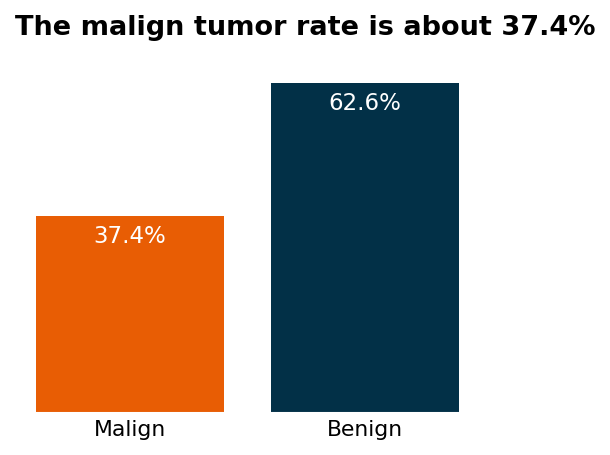

In [14]:
# Group the data by diagnosis.
cancer_grp = train.groupby(['diagnosis'])[['diagnosis']].count().rename(columns={'diagnosis': 'count'}).reset_index()
cancer_grp['pct'] = (cancer_grp['count'] / cancer_grp['count'].sum()) * 100
cancer_grp = cancer_grp.sort_values(by=['pct'])

# Define the plot.
fig, ax = plt.subplots(figsize=(4, 3))
        
# Plot the barplot.
bars = ax.bar(x=cancer_grp['diagnosis'], height=cancer_grp['pct'], color=['#e85d04', '#023047'])
        
# Customize the plot.
ax.set_title('The malign tumor rate is about 37.4%', fontweight='bold', fontsize=13, pad=15, loc='left')
ax.set_xlabel('')
ax.set_xticks(ticks=range(2), labels=['Benign', 'Malign'], fontsize=10.5)
ax.tick_params(axis=u'both', which=u'both',length=0)
ax.invert_xaxis()
        
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(False)

for bar in bars:
    height = bar.get_height()
    ax.annotate('{:.1f}%'.format(height), 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -10),  
                textcoords="offset points",
                ha='center', va='center',
                fontsize=11, color='white')

O target está desbalanceado. 37,4% dos pacientes possuem tumor maligno. Portanto, adotarei algumas estratégias para lidar com isso. Elas são:

- Hold-out estratificado e validação cruzada k-fold para manter a proporção do target nos conjuntos de teste e validação, inclusive para a otimização de hiperparâmetros (hyperparameter tuning).
- Definir diferentes pesos de classe para as instâncias da classe majoritária e minoritária. A ideia é atribuir pesos maiores à classe minoritária, de modo que o modelo seja penalizado ao classificar erroneamente um caso positivo (maligno). Esses pesos são definidos no hiperparâmetro específico do modelo.
- Analisar o *trade-off* entre precisão e revocação (*precision-recall*), se necessário. O principal objetivo aqui é prever probabilidades de malignidade, e não apenas uma predição binária. Isso permitirá decisões mais bem informadas, possibilitando verificar o quão provável é que um tumor seja maligno, em vez de simplesmente classificar se ele é ou não canceroso.

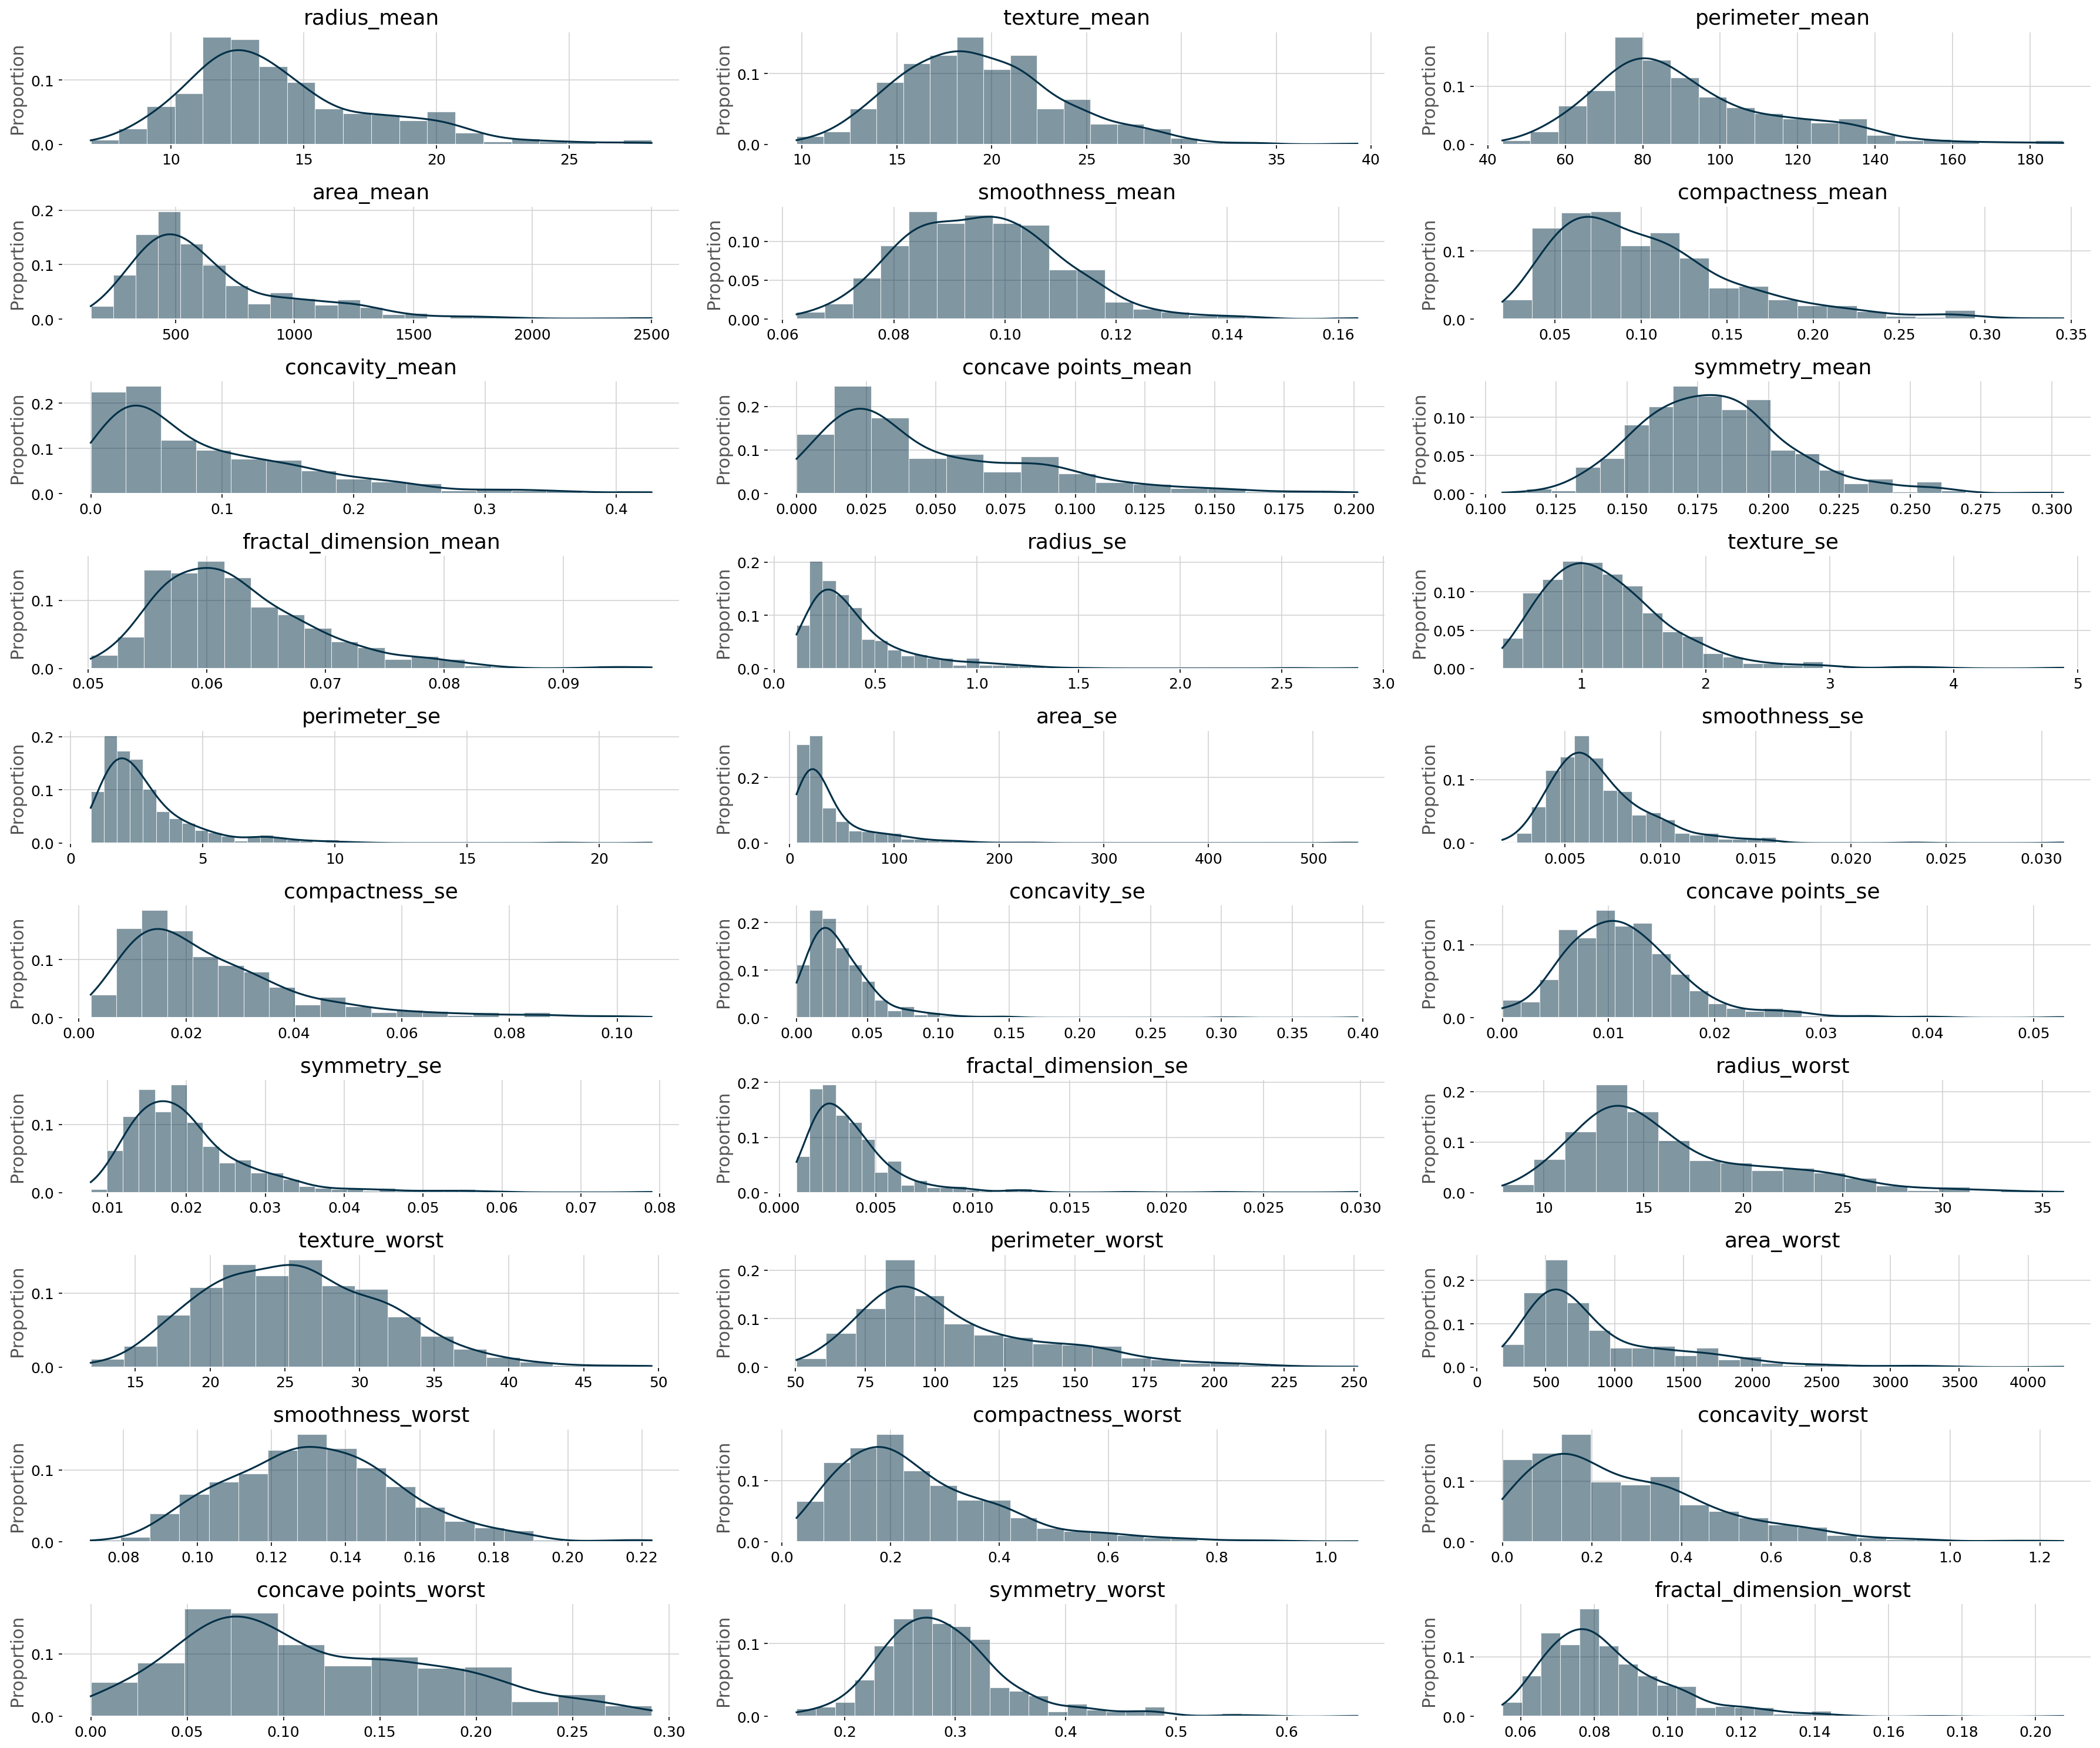

In [15]:
numeric_columns = list(train.drop(columns=['diagnosis']).columns)

analysis_plots(data=train, features=numeric_columns, kde=True, figsize=(24, 20))

Análise da Distribuição das Variáveis:

- Várias variáveis, especialmente aquelas relacionadas à área (area_mean, area_worst), concavidade (concavity_mean) e pontos côncavos (concave points_mean), exibem forte assimetria à direita. A grande maioria das observações concentra-se em patamares inferiores, enquanto valores elevados estendem-se na cauda, refletindo a desproporção natural entre tumores benignos e massas malignas maiores.
- Atributos como radius_mean, perimeter_mean, texture_mean e symmetry_mean demonstram perfis de distribuição mais equilibrados e próximos à normalidade.
- As variávies de erro padrão concentram seus valores densamente perto de zero, indicando que a dispersão interna das medições celulares tende a ser restrita na maior parte das amostras analisadas.

### Outliers
I will look at outliers in the data in order to see if they represent inconsistent information like measurement errors. Once I do this, I will decide if I will treat them or not. Moreover, I will plot boxplots below for visualization purposes.

In [16]:
outlier_indexes, outlier_counts, total_outliers = check_outliers(data=train, features=numeric_columns)

There are 494 outliers in the dataset.

Number (percentage) of outliers per feature: 

radius_mean: 11 (2.42)%
texture_mean: 5 (1.1)%
perimeter_mean: 12 (2.64)%
area_mean: 20 (4.4)%
smoothness_mean: 5 (1.1)%
compactness_mean: 14 (3.08)%
concavity_mean: 17 (3.74)%
concave points_mean: 9 (1.98)%
symmetry_mean: 13 (2.86)%
fractal_dimension_mean: 12 (2.64)%
radius_se: 31 (6.81)%
texture_se: 15 (3.3)%
perimeter_se: 34 (7.47)%
area_se: 53 (11.65)%
smoothness_se: 20 (4.4)%
compactness_se: 24 (5.27)%
concavity_se: 24 (5.27)%
concave points_se: 17 (3.74)%
symmetry_se: 22 (4.84)%
fractal_dimension_se: 23 (5.05)%
radius_worst: 10 (2.2)%
texture_worst: 3 (0.66)%
perimeter_worst: 12 (2.64)%
area_worst: 21 (4.62)%
smoothness_worst: 3 (0.66)%
compactness_worst: 15 (3.3)%
concavity_worst: 11 (2.42)%
concave points_worst: 0 (0.0)%
symmetry_worst: 20 (4.4)%
fractal_dimension_worst: 18 (3.96)%


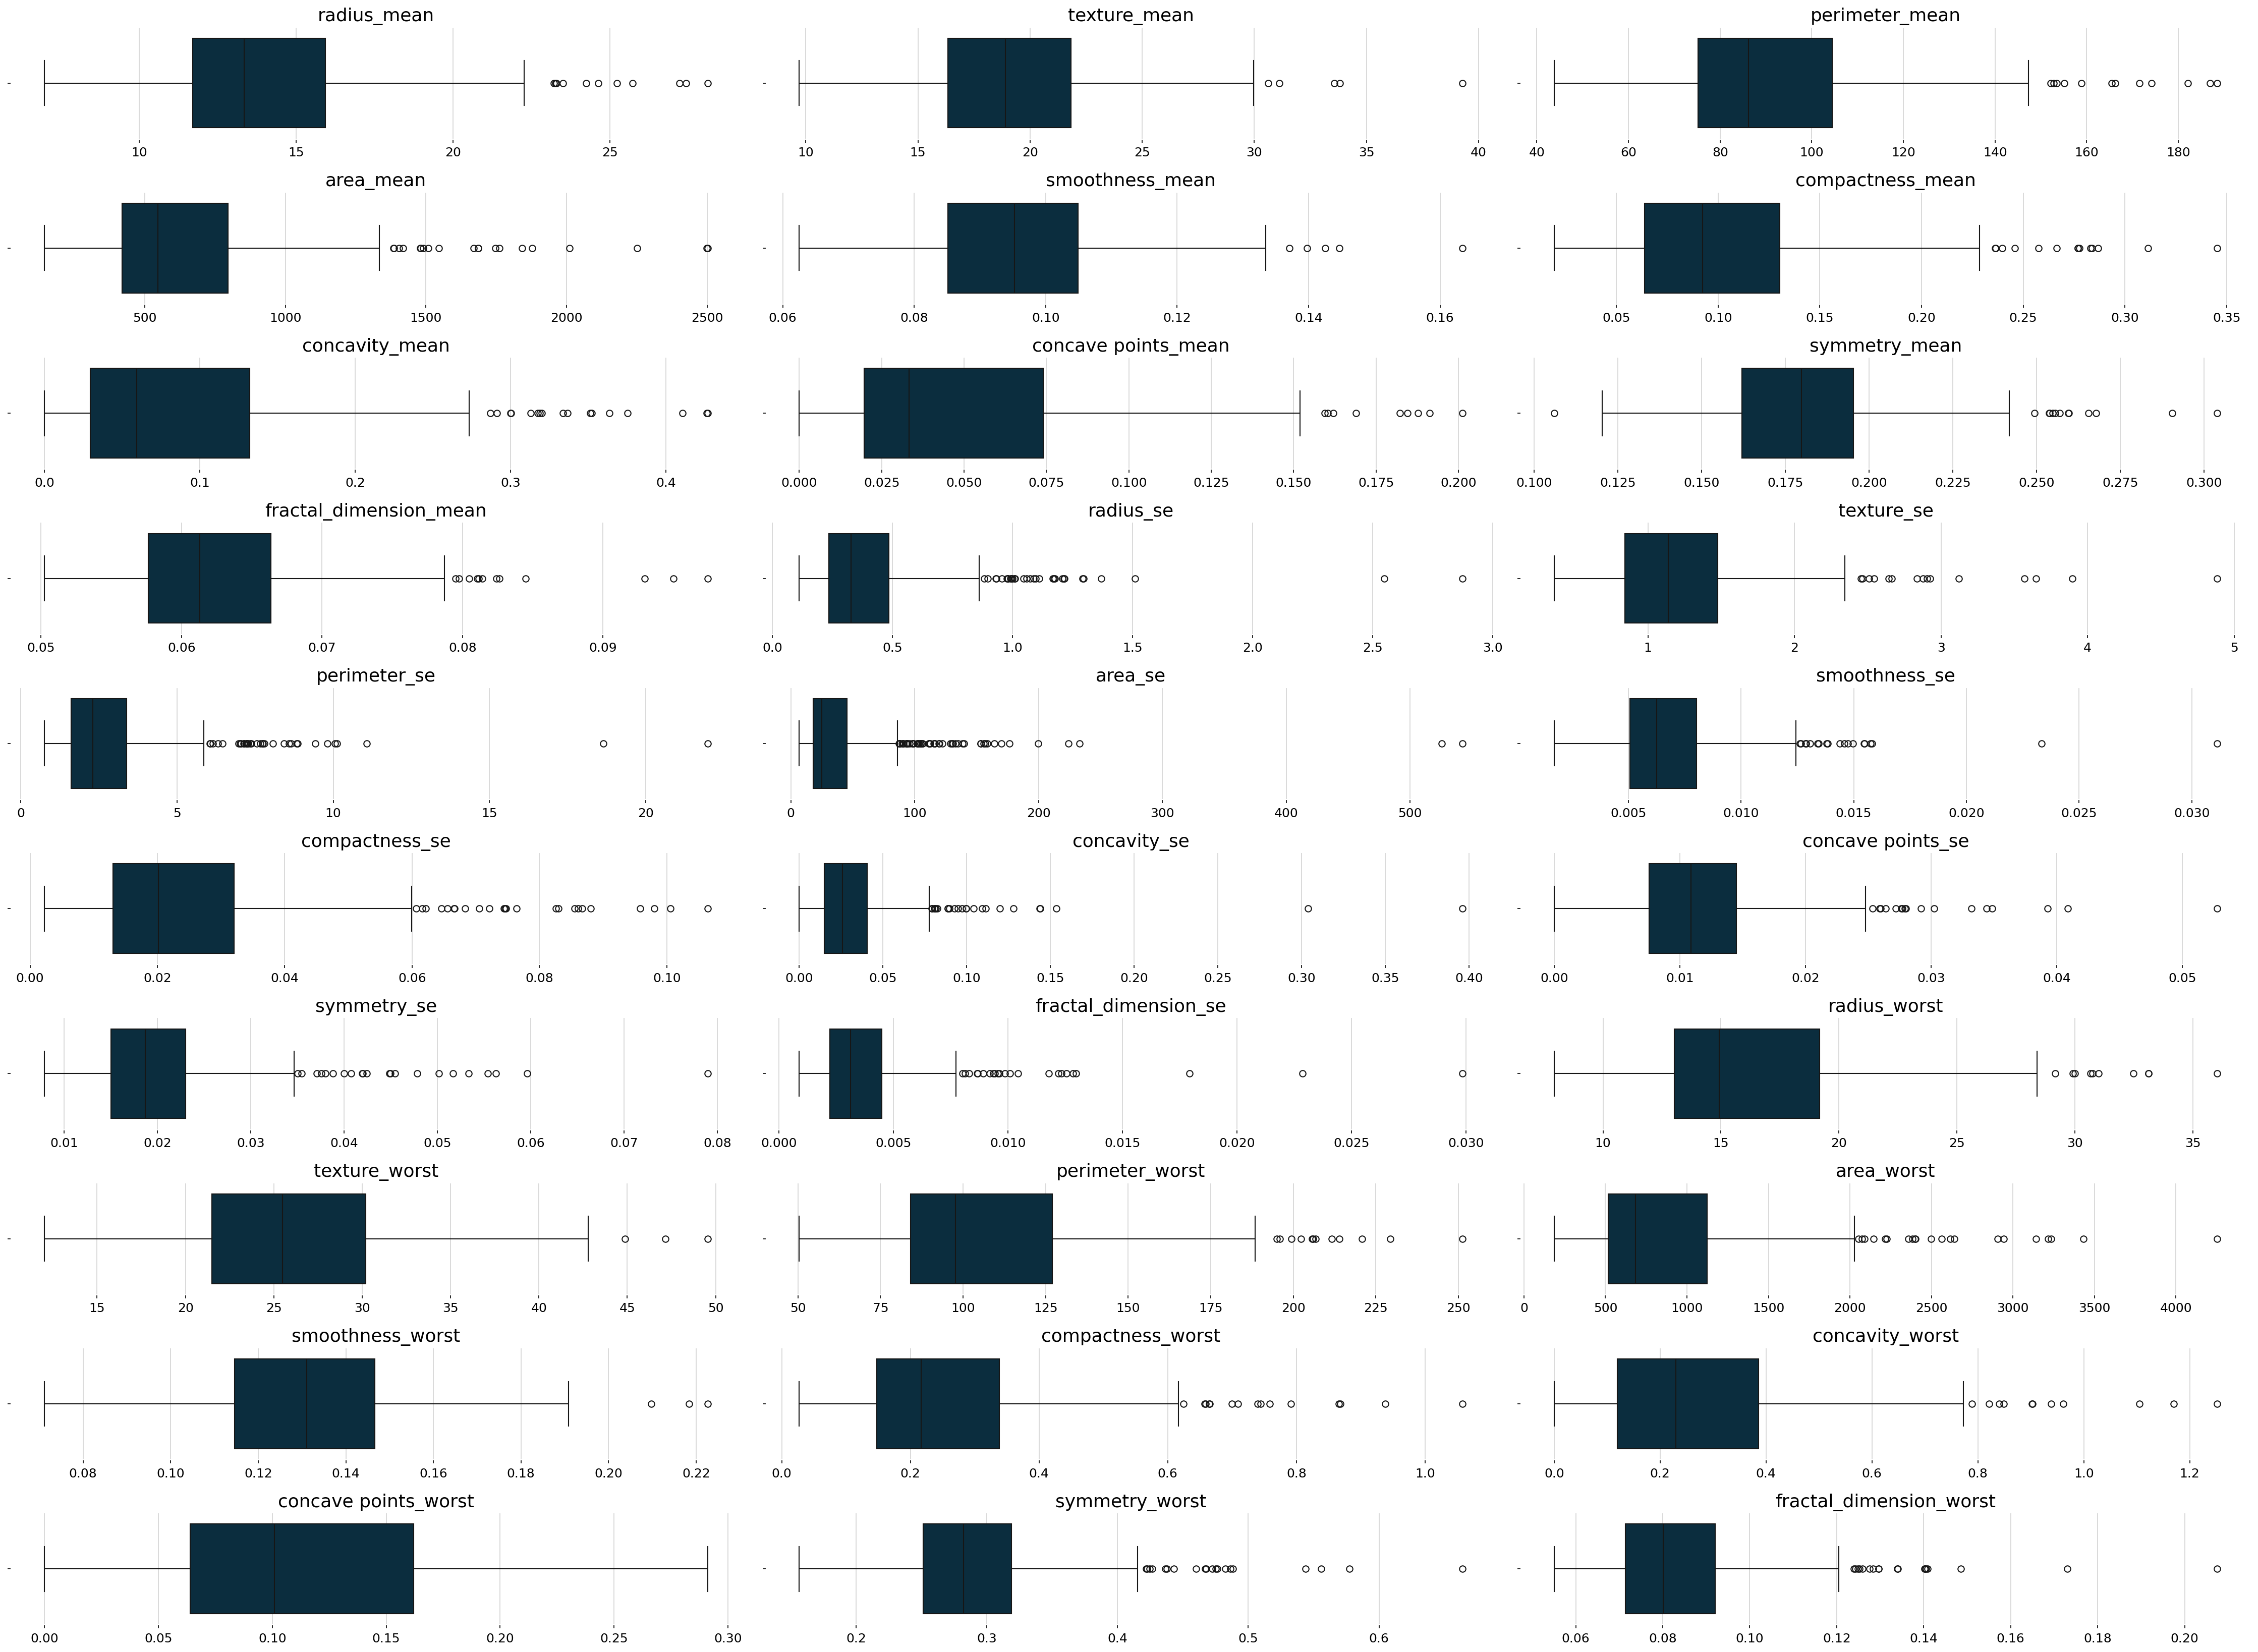

In [17]:
analysis_plots(data=train, features=numeric_columns, outliers=True, figsize=(30, 22))

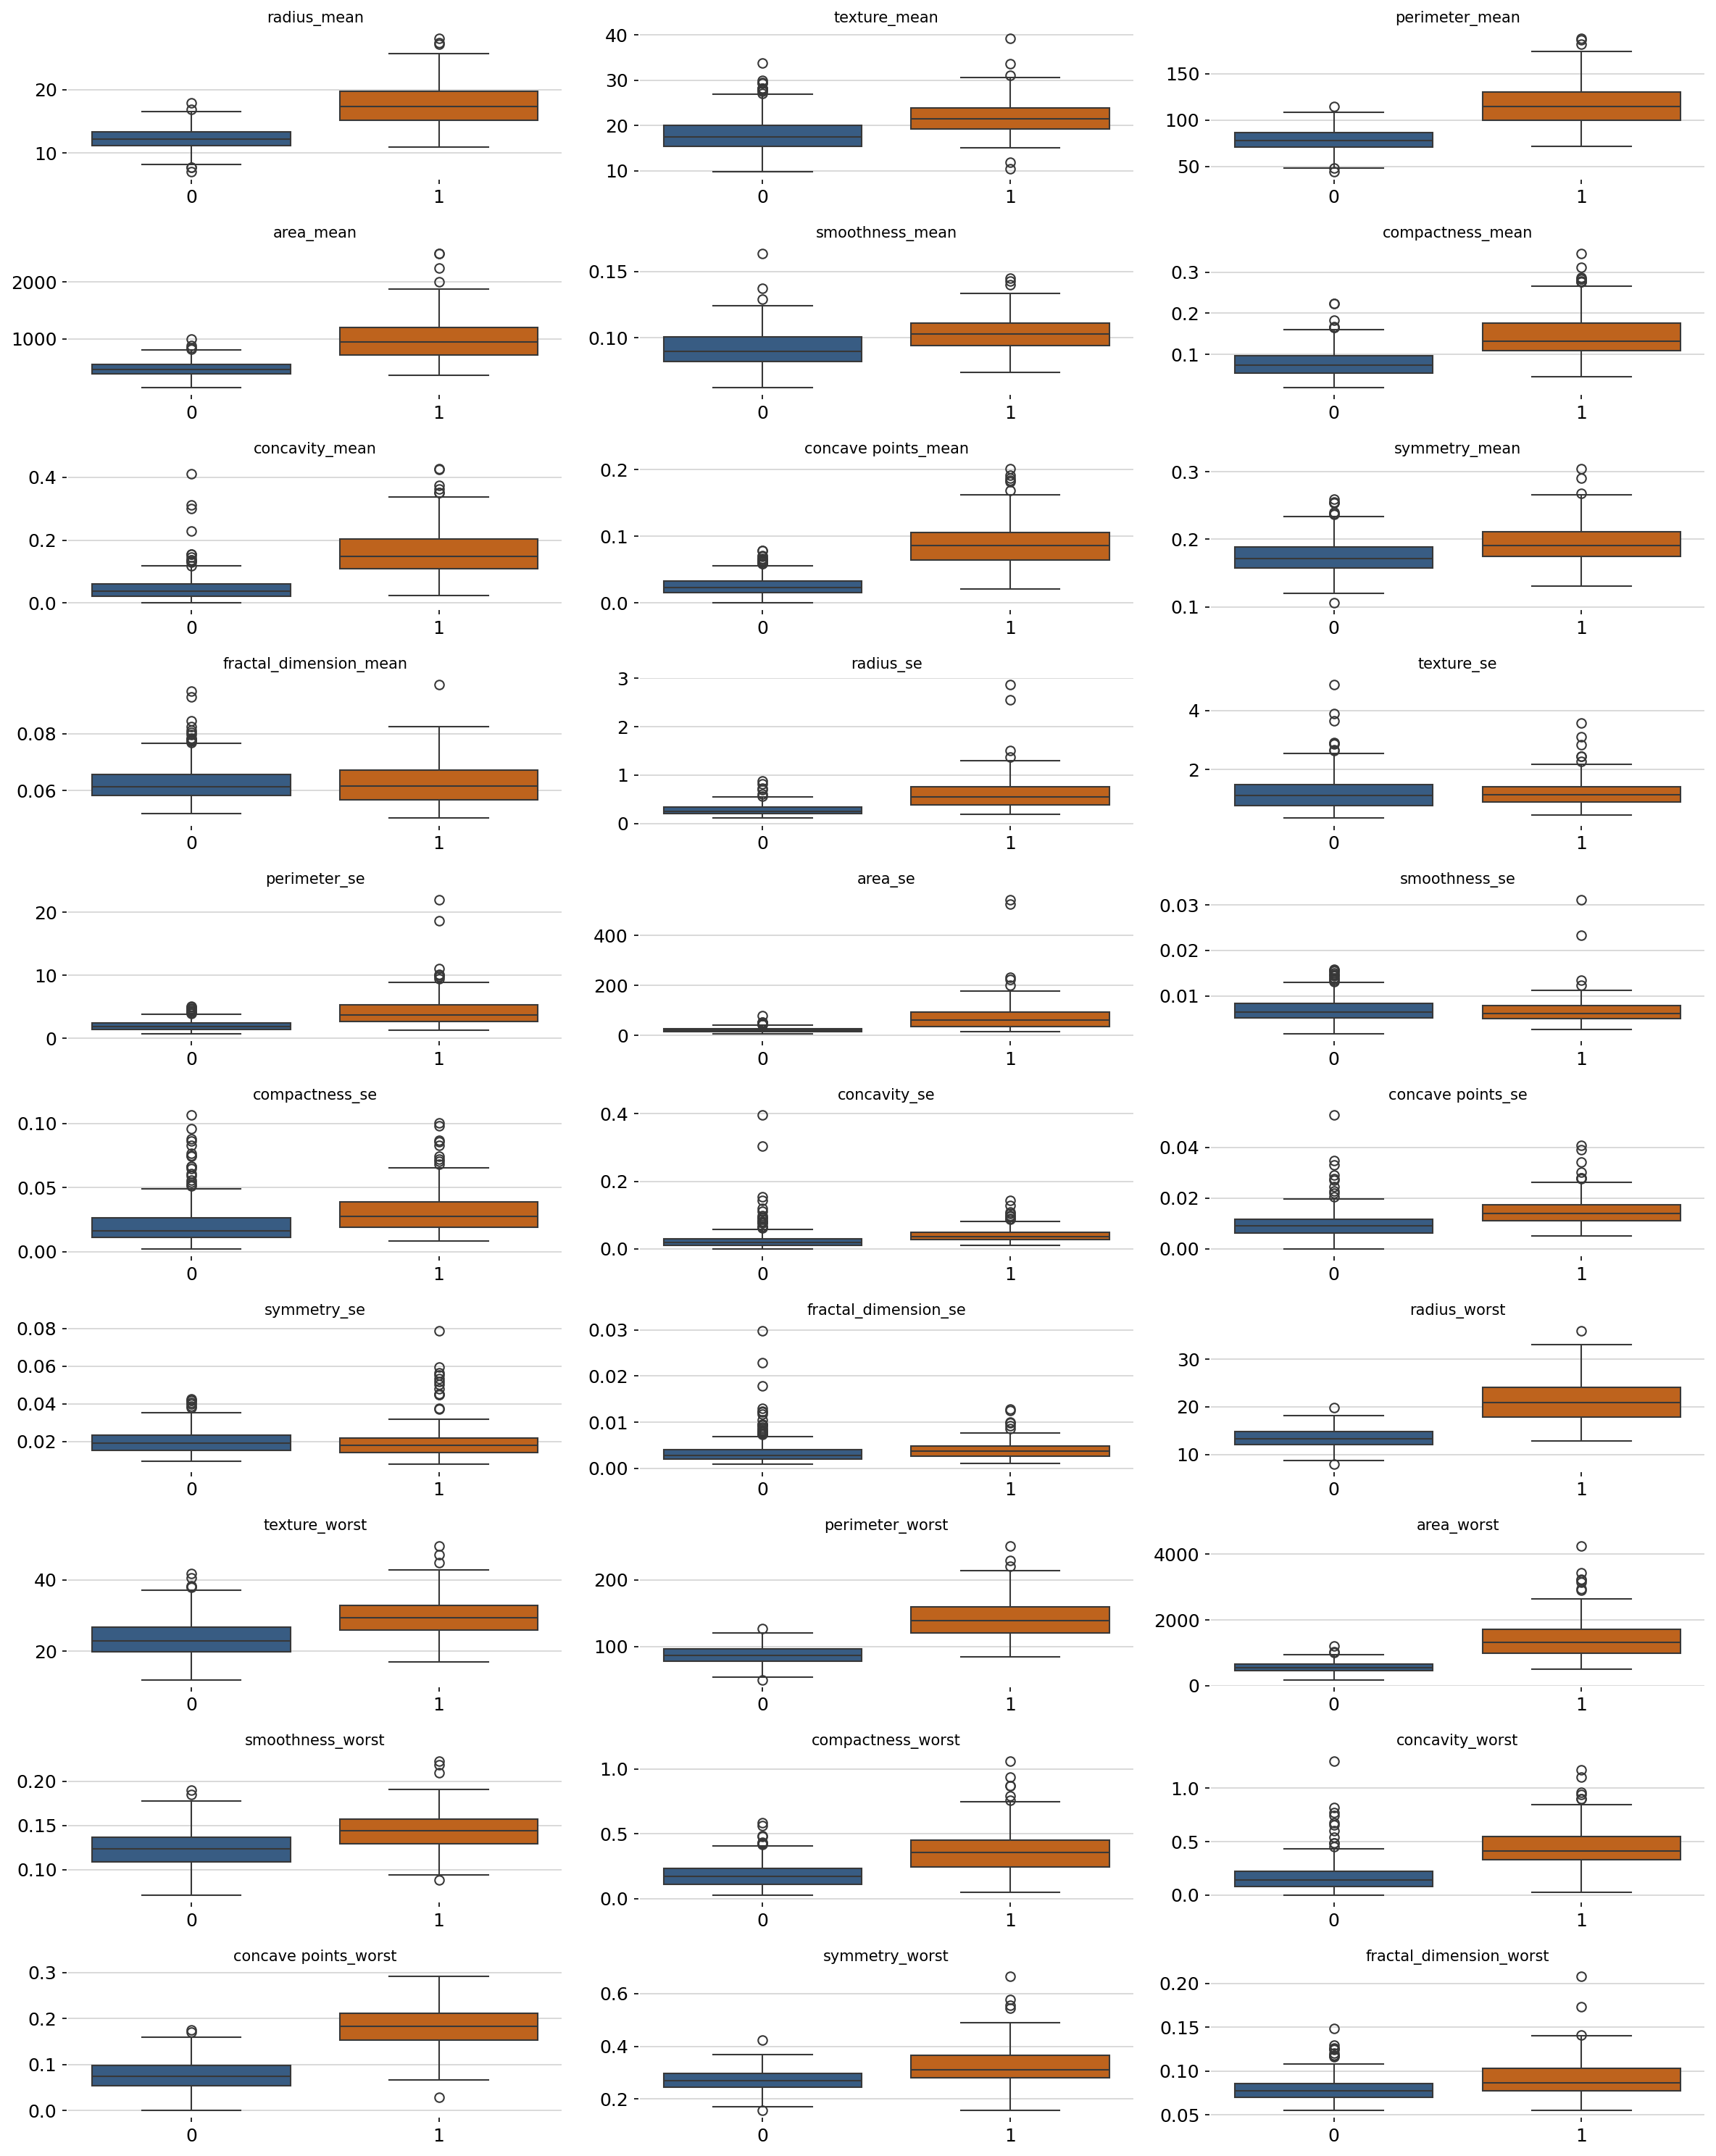

In [18]:
plot_boxplots_by_target(train, target_col='diagnosis')

Análise dos Outliers:

- Foram identificados pontos fora dos limites tradicionais em quase todas as features do conjunto de dados.
- Cruzando a distribuição dos outliers com a variável alvo (diagnosis), constatou-se que a totalidade ou a esmagadora maioria desses valores extermos concentra-se na classe 1 (maligno).
- Esses valores elevados em métricas de tamanho e forma correspondem à variablidade biológica natual e ao crescimento volumétrico de tumores mais agressivos.
- Optou-se por **manter todos os outliers**, pois a remoção dessas instâncias eliminaria justamente os casos mais críticos de malignidade, que nesse caso aparenta não ser por erro técnico, o que prejudicaria a capacidade preditiva do modelo.

### Bivariate and multivariate analysis
I will do bivariate and multivariate analysis below in order to see how the features are related to each other, particularly with the target variable (diagnosis).

### Correlation matrix
I will examine the correlation matrix in order to identify any linear relationships between the features in the data, particularly with the target variable, and assess the strength and direction of these relationships.

In [21]:
corr_matrix = train.corr(numeric_only=True)

In [23]:
corr_matrix['diagnosis'].sort_values(ascending=False)

diagnosis                  1.000000
concave points_worst       0.786306
perimeter_worst            0.782881
radius_worst               0.777602
concave points_mean        0.775737
perimeter_mean             0.740027
area_worst                 0.731761
radius_mean                0.728160
area_mean                  0.703893
concavity_mean             0.683688
concavity_worst            0.643116
compactness_mean           0.606479
compactness_worst          0.587045
radius_se                  0.558572
perimeter_se               0.546759
area_se                    0.533848
texture_worst              0.466666
smoothness_worst           0.431637
symmetry_worst             0.426215
texture_mean               0.413595
concave points_se          0.402364
smoothness_mean            0.388584
symmetry_mean              0.341308
fractal_dimension_worst    0.326102
compactness_se             0.284951
concavity_se               0.227480
fractal_dimension_se       0.070343
symmetry_se                0

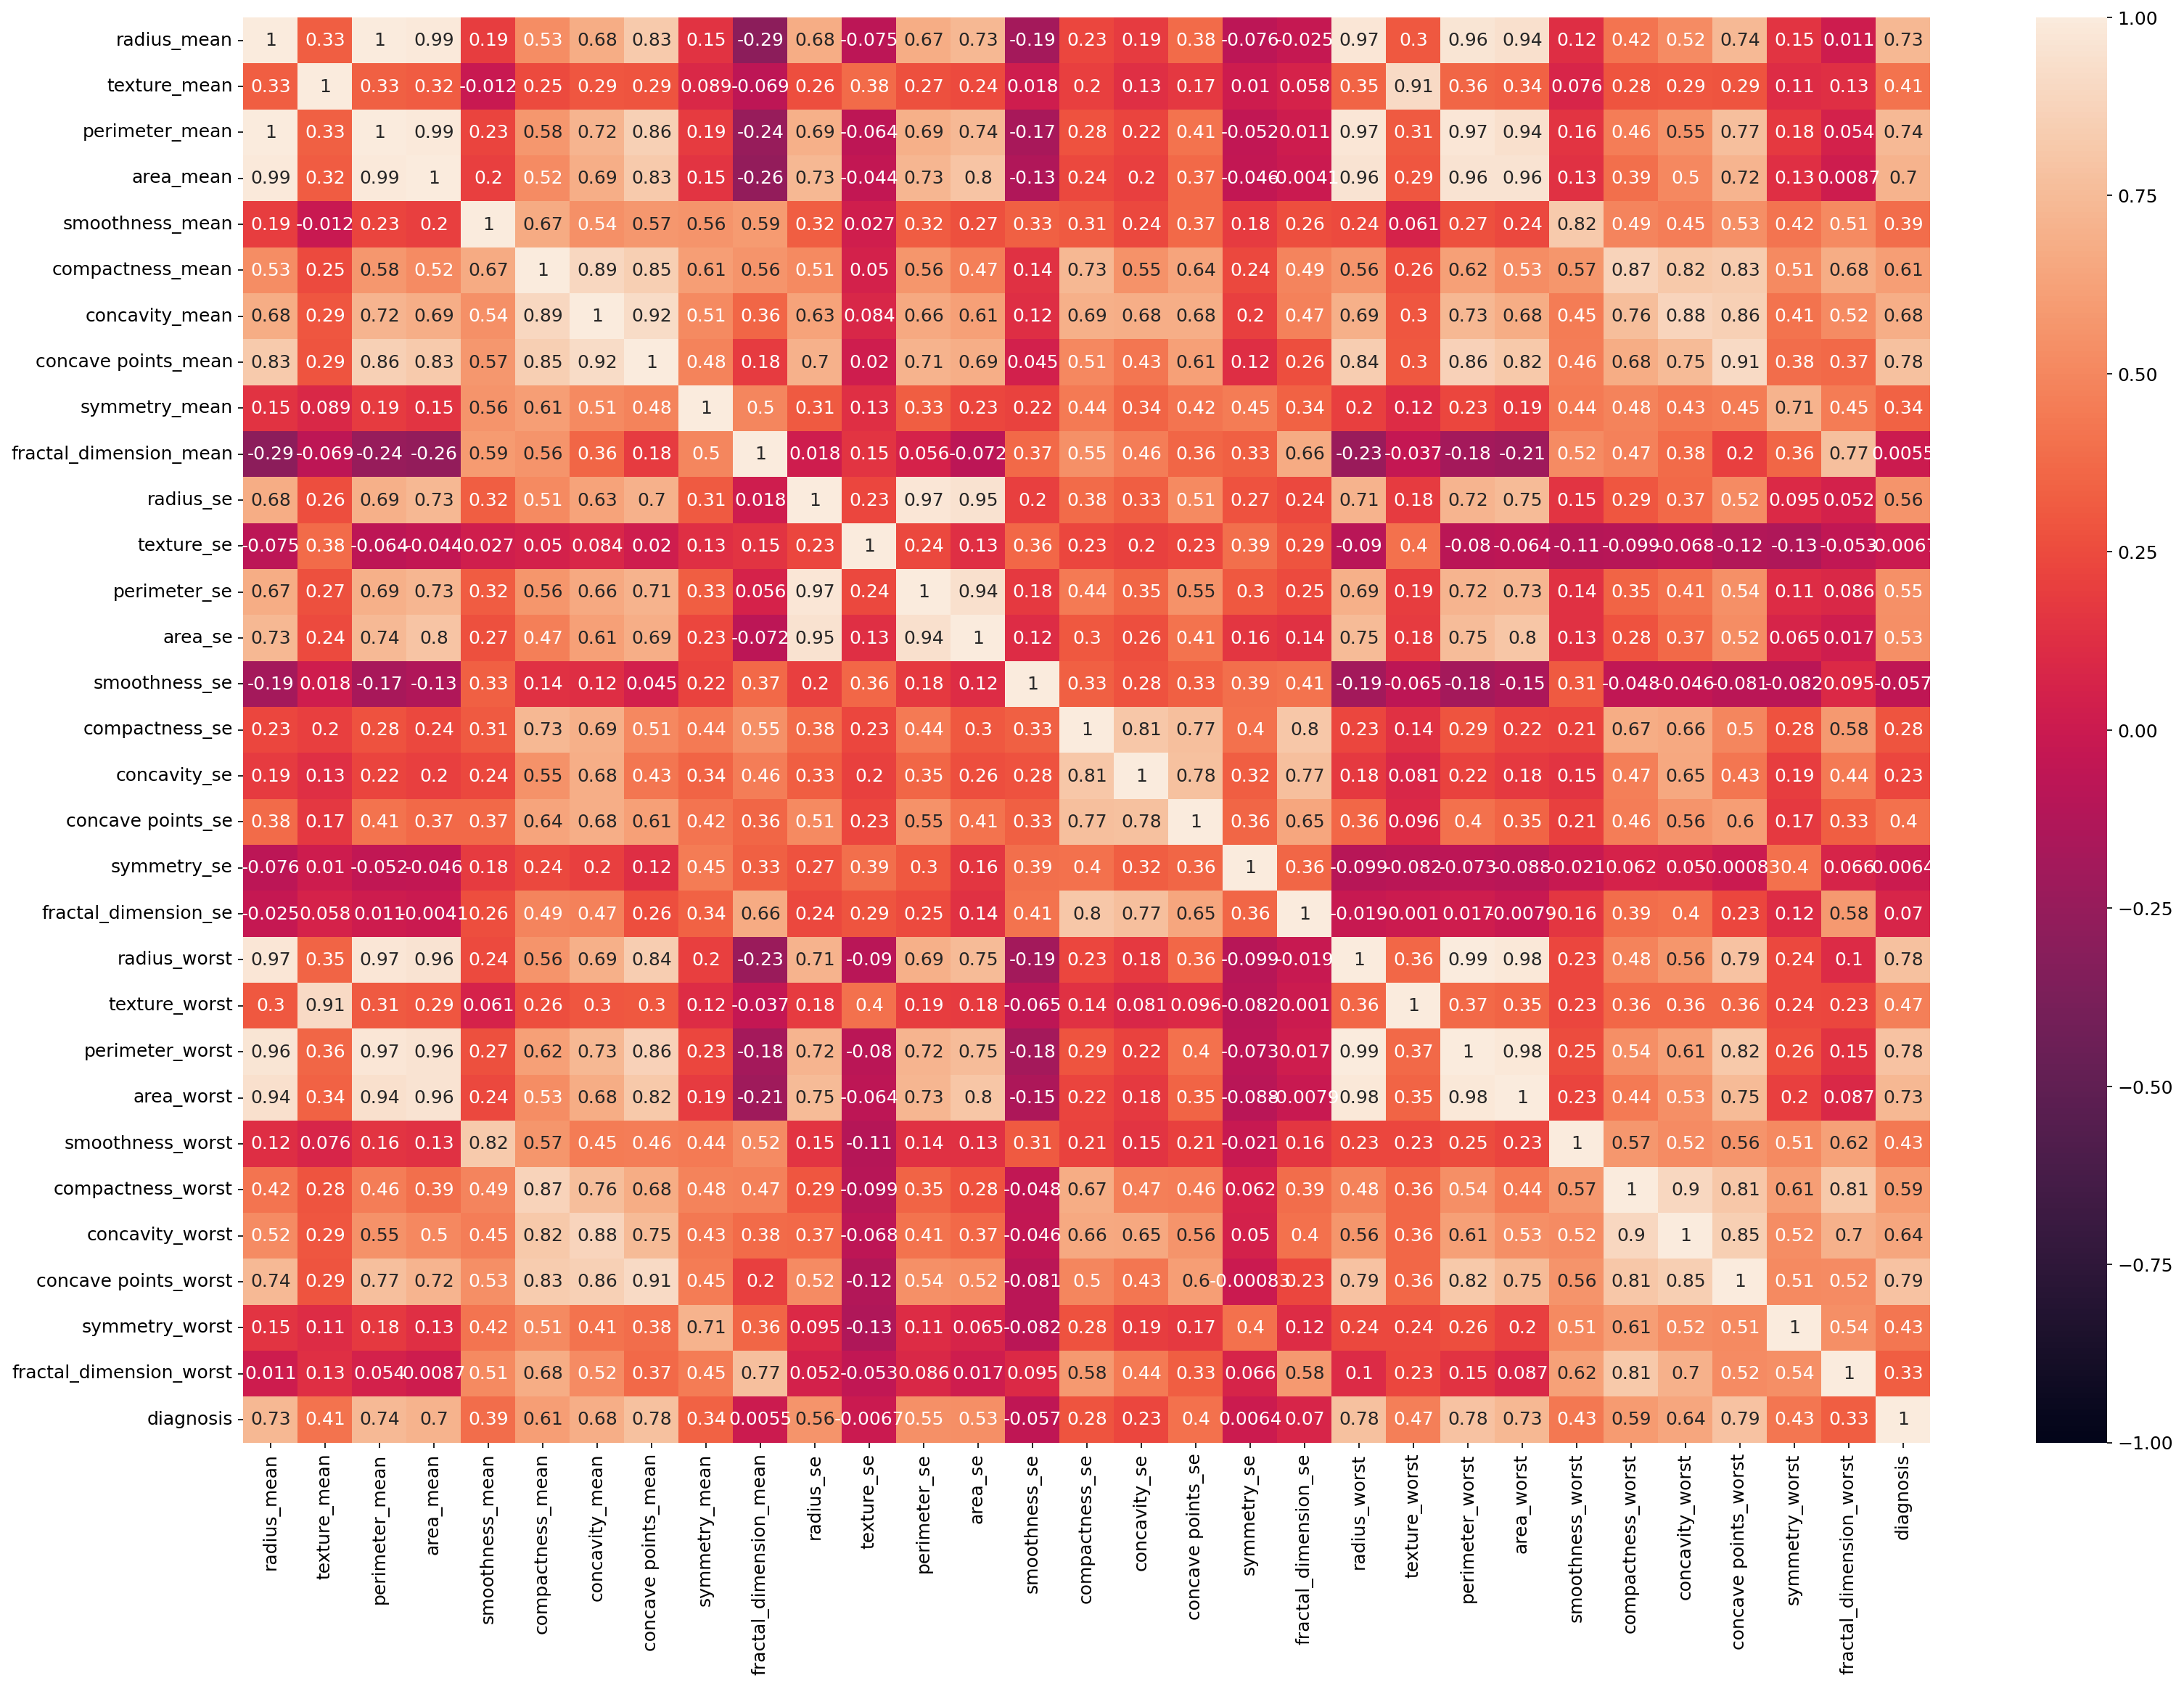

In [25]:
plt.figure(figsize=(25, 17))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True)
plt.show()

Insights: 
- Há correlações muito fortes (superior a 0.95) entre as features de tamanho (radius, perimeter e area), tanto para as médias quanto para os piores valores (_worst). Isso sugere redundância de informação que deve ser tratada em modelos lineares.
- As variáveis concave points_worst, perimeter_worst, radius_worst e concave points_mean exibem os maiores coeficientes de correlação com a variável alvo (diagnosis), destacando-se como os preditores lineares mais fortes.
- Features relacionadas à textura e dimensão fractal apresentam correlações mais fracas com o tamanho puro, indicando que trazem características morfológicas independentes e úteis para o poder discriminativo do classificador.